# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

In [1]:
%load_ext autoreload
%autoreload 2

## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

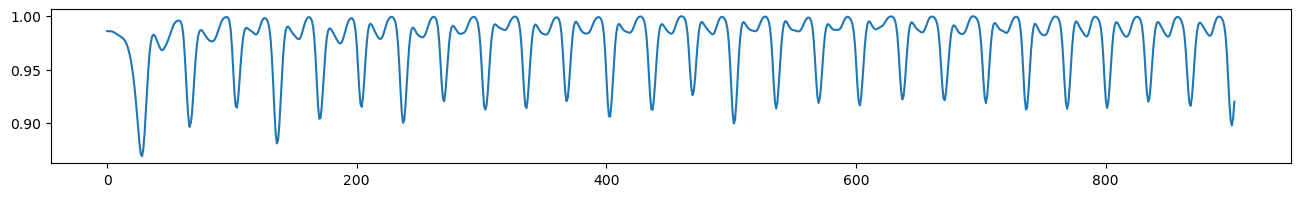

In [5]:
fig, ax = plt.subplots(figsize=(16, 2))
ts = np.loadtxt('datasets/Rotation Matrix.txt')
ax.plot(ts)

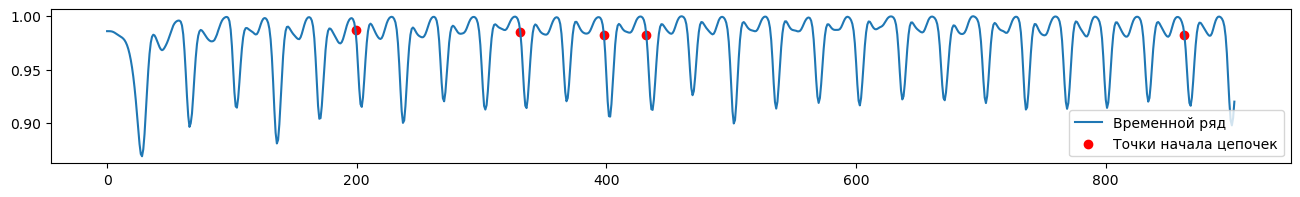

Индексы начала самой длинной цепочки: [199 331 398 432 863]


In [16]:
# длина подпоследовательности
m = 25

# Вычисление матричного профиля
matrix_profile = stumpy.stump(ts, m=m)

# Поиск индексов самой длинной цепочки
# находим индексы, где начинаются цепочки (используем матричный профиль)

all_chain_set, chain_indices = stumpy.allc(matrix_profile[:, 2], matrix_profile[:, 3])

# Визуализация временного ряда и выделение точек начала цепочек
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts, label="Временной ряд")
ax.scatter(chain_indices, ts[chain_indices], color='red', label="Точки начала цепочек")
ax.legend()
plt.show()

# Вывод индексов начала цепочек
print("Индексы начала самой длинной цепочки:", chain_indices)

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Найденные индексы показывают, что во временном ряду Rotation Matrix существует повторяющийся шаблон, который возникает в пяти удалённых друг от друга местах, и каждый раз проявляется в всё более изменённом виде, что отражает постепенную эволюцию шаблона.

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

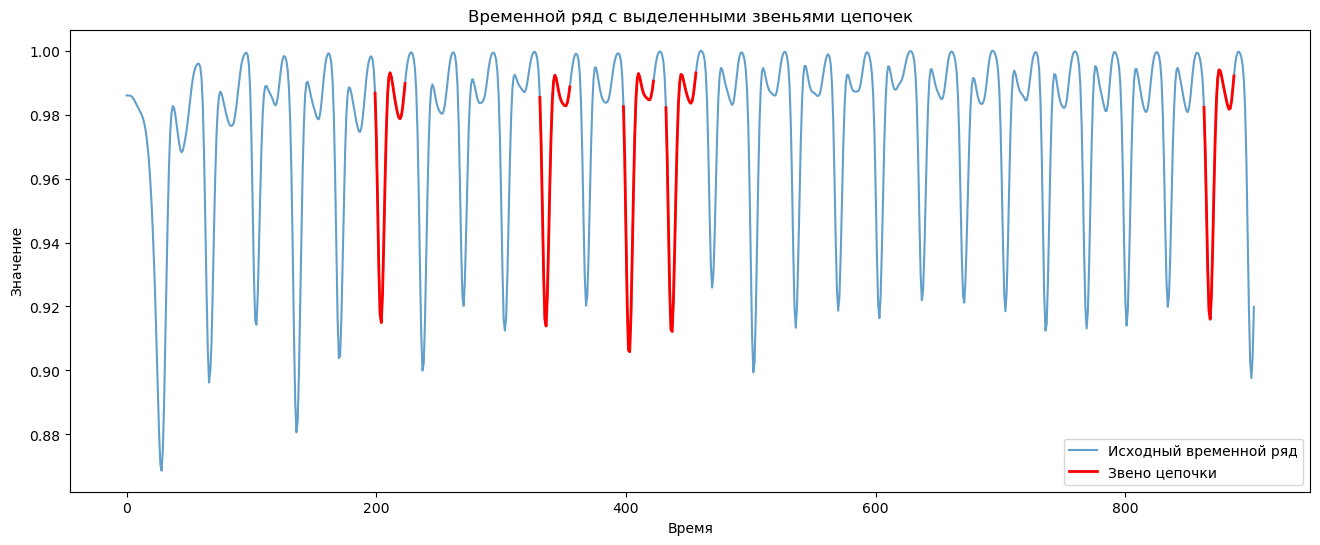

In [18]:
# Визуализация исходного ряда с выделением цепочек
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(ts, label="Исходный временной ряд", alpha=0.7)
for idx in chain_indices:
    ax.plot(range(idx, idx + m), ts[idx:idx + m], color='red', linewidth=2, label="Звено цепочки" if idx == chain_indices[0] else "")
ax.legend()
plt.title("Временной ряд с выделенными звеньями цепочек")
plt.xlabel("Время")
plt.ylabel("Значение")
plt.show()

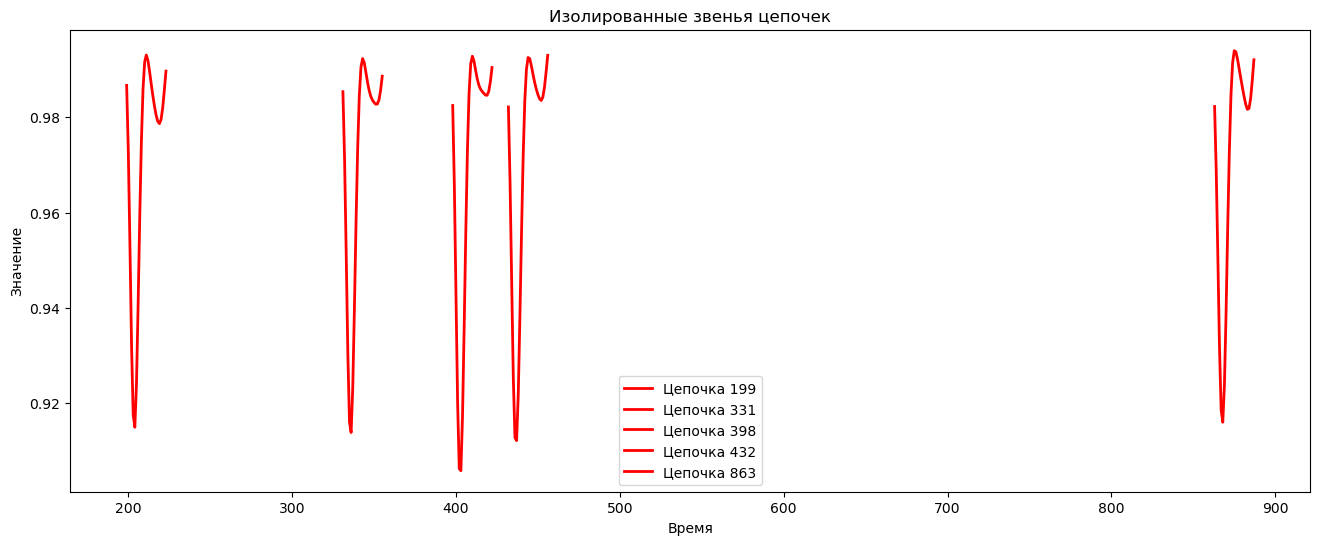

In [20]:
# Визуализация только звеньев цепочек для детального анализа
fig, ax = plt.subplots(figsize=(16, 6))
for idx in chain_indices:
    ax.plot(range(idx, idx + m), ts[idx:idx + m], color='red', linewidth=2, label=f"Цепочка {idx}")
ax.set_title("Изолированные звенья цепочек")
ax.legend()
plt.xlabel("Время")
plt.ylabel("Значение")
plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Форма всех пяти звеньев почти одинакова, значит это действительно один и тот же паттерн и алгоритм выделил повторяющийся шаблон, а не случайные совпадения.

Также звенья постепенно меняются, значит присутсует эволюция.

Таким образом, изолированные звенья показывают устойчивый, многократно повторяющийся паттерн с характерным провалом и двухпиковой структурой, который появляется в разных частях временного ряда и постепенно изменяет форму, что свидетельствует о плавной эволюции шаблона.

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

In [25]:
# Извлекаем два последних звена цепочки для прогнозирования
last_two_indices = chain_indices[-2:]
last_two_segments = [ts[idx:idx + m] for idx in last_two_indices]

# Вычисляем разность между предпоследним и последним известным звеном
segment_difference = last_two_segments[1] - last_two_segments[0]

# Прогнозируем следующее звено на основе выявленной динамики
predicted_next_segment = last_two_segments[1] + segment_difference

# Фактическое значение последнего звена (для проверки точности)
actual_last_segment = ts[chain_indices[-1]:chain_indices[-1] + m]

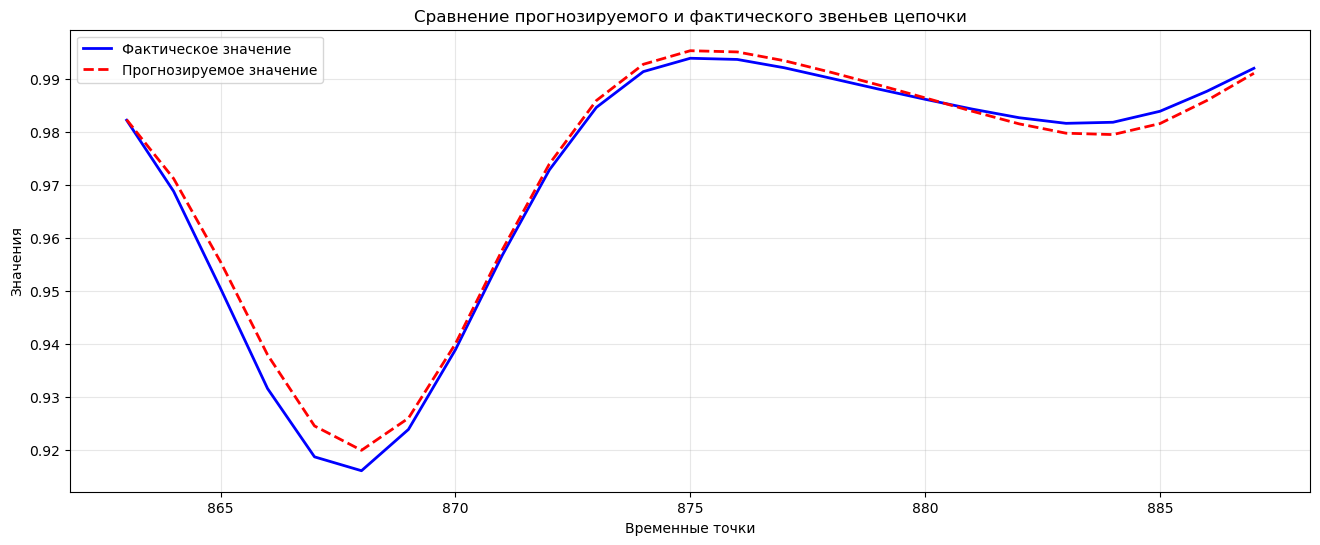

In [27]:
# Визуализация сравнения прогноза с реальными данными
fig, ax = plt.subplots(figsize=(16, 6))

# Фактическое последнее звено
ax.plot(range(last_two_indices[1], last_two_indices[1] + m), 
        actual_last_segment, label="Фактическое значение", color='blue', linewidth=2)

# Прогнозируемое звено
ax.plot(range(last_two_indices[1], last_two_indices[1] + m), 
        predicted_next_segment, label="Прогнозируемое значение", color='red', linestyle='--', linewidth=2)

ax.legend()
plt.title("Сравнение прогнозируемого и фактического звеньев цепочки")
plt.xlabel("Временные точки")
plt.ylabel("Значения")
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# Оценка точности прогноза
mean_absolute_error = np.mean(np.abs(actual_last_segment - predicted_next_segment))
print(f"Средняя абсолютная ошибка между истинным и предсказанным значением: {mean_absolute_error}")

Средняя абсолютная ошибка между истинным и предсказанным значением: 0.0019526147999999965


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Прогнозируемая траектория очень близка к истинной, а общая форма совпадает. Прогноз показал, что изменения между двумя предыдущими звеньями настолько стабильны, что их можно использовать для предсказания следующего звена.
Низкая ошибка (≈0.2%) подтверждает, что цепочка действительно эволюционирующий, а не случайный шаблон